# using the scikit learn fetch california hosing dataset build and compare ensamble regression model for price prediction


# import libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load Dataset and create dataframe

In [34]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data preprocessing


In [21]:
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


# Split Dataset and define features and target


In [22]:
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Split Completed")

Data Split Completed


## Feature Scaling


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


# Random Forest Regressor

In [24]:
print("\nRandom Forest Regressor")

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("MSE :", rf_mse)
print("R2 Score :", rf_r2)


Random Forest Regressor
MSE : 0.2553684927247781
R2 Score : 0.8051230593157366


# Gradient Boosting Regressor

In [25]:
print("\nGradient Boosting Regressor")

gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("MSE :", gb_mse)
print("R2 Score :", gb_r2)


Gradient Boosting Regressor
MSE : 0.2939973248643864
R2 Score : 0.7756446042829697


# AdaBoost Regressor

In [15]:
print("\nAdaBoost Regressor")

ab = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ab.fit(X_train, y_train)

ab_pred = ab.predict(X_test)

ab_mse = mean_squared_error(y_test, ab_pred)
ab_r2 = r2_score(y_test, ab_pred)

print("MSE :", ab_mse)
print("R2 Score :", ab_r2)


AdaBoost Regressor
MSE : 0.568195768061393
R2 Score : 0.5663981417281327


# Comparison Table

In [26]:
result = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost"
    ],

    "MSE": [
        rf_mse,
        gb_mse,
        ab_mse
    ],

    "R2 Score": [
        rf_r2,
        gb_r2,
        ab_r2
    ]
})
 
print("\nModel Comparison")
print(result)


Model Comparison
               Model       MSE  R2 Score
0      Random Forest  0.255368  0.805123
1  Gradient Boosting  0.293997  0.775645
2           AdaBoost  0.568196  0.566398


# Best Performing Model

In [27]:
best_model = result.loc[result["R2 Score"].idxmax()]

print("\nBest Performing Model")
print("Model Name :", best_model["Model"])
print("R2 Score :", best_model["R2 Score"])


Best Performing Model
Model Name : Random Forest
R2 Score : 0.8051230593157366


## model perfomance visualization

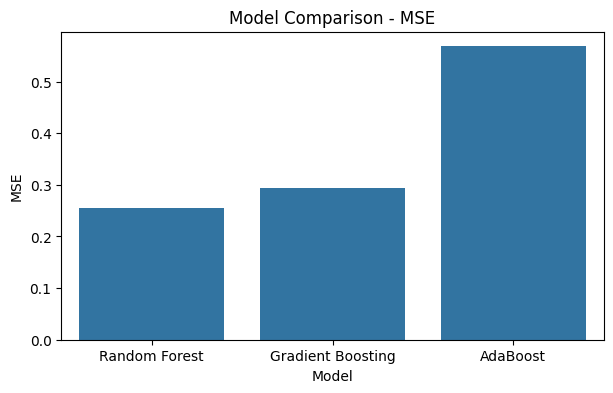

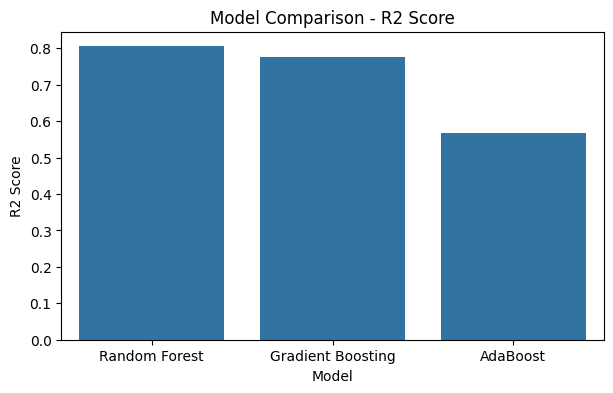

In [32]:
# MSE Plot
plt.figure(figsize=(7,4))
sns.barplot(x="Model", y="MSE", data=result)
plt.title("Model Comparison - MSE")
plt.show()

# R2 Score Plot
plt.figure(figsize=(7,4))
sns.barplot(x="Model", y="R2 Score", data=result)
plt.title("Model Comparison - R2 Score")
plt.show()